In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

In [177]:
df = pd.read_csv("Virat-Kohli-International-Cricket-Centuries.csv")

In [178]:
df.head()

,No.,Runs,Against,Position,Innings,Venue,Ground,Date,Result
0,1,107,Sri Lanka,4,2,"Eden Gardens, Kolkata",Home,24-Dec-09,Won
1,2,102*,Bangladesh,3,2,"Sher-e-Bangla Cricket Stadium, Dhaka",Away,11-Jan-10,Won
2,3,118,Australia,3,2,"APCA-VDCA Stadium, Visakhapatnam",Home,20-Oct-10,Won
3,4,105,New Zealand,3,1,"Nehru Stadium, Guwahati",Home,28-Nov-10,Won
4,5,100*,Bangladesh,4,1,"Sher-e-Bangla Cricket Stadium, Dhaka",Away,19-Feb-11,Won


In [179]:
df = df.drop(columns=["Against","Venue","Date","Innings"])

In [180]:
df.head()

,No.,Runs,Position,Ground,Result
0,1,107,4,Home,Won
1,2,102*,3,Away,Won
2,3,118,3,Home,Won
3,4,105,3,Home,Won
4,5,100*,4,Away,Won


(array([ 1.,  0., 43.,  0.,  0., 32.,  0.,  3.,  0.,  1.]),
 array([2. , 2.4, 2.8, 3.2, 3.6, 4. , 4.4, 4.8, 5.2, 5.6, 6. ]),
 <BarContainer object of 10 artists>)

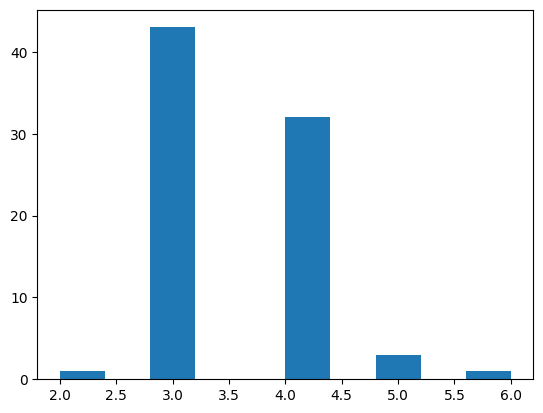

In [181]:
plt.hist(df["Position"])

<Axes: xlabel='count', ylabel='Ground'>

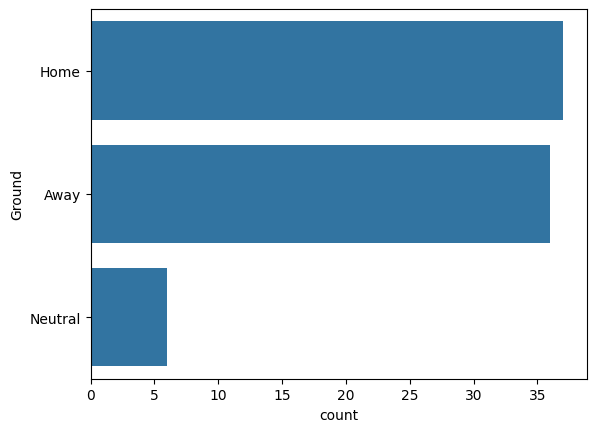

In [182]:
sns.countplot(df["Ground"])

C:\Users\DELL\AppData\Local\Temp\ipykernel_10100\939235037.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Position"])


<Axes: xlabel='Position', ylabel='Density'>

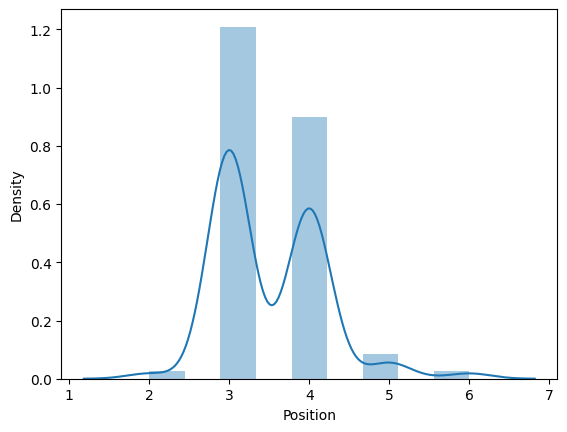

In [183]:
sns.distplot(df["Position"])

In [184]:
df["Runs"] = df["Runs"].str.replace('*', '', regex=False).str.strip()

In [185]:
df["Runs"] = pd.to_numeric(df["Runs"], errors='coerce')

In [186]:
df["Runs"].dtypes

dtype('int64')

C:\Users\DELL\AppData\Local\Temp\ipykernel_10100\1501667773.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Runs"])


<Axes: xlabel='Runs', ylabel='Density'>

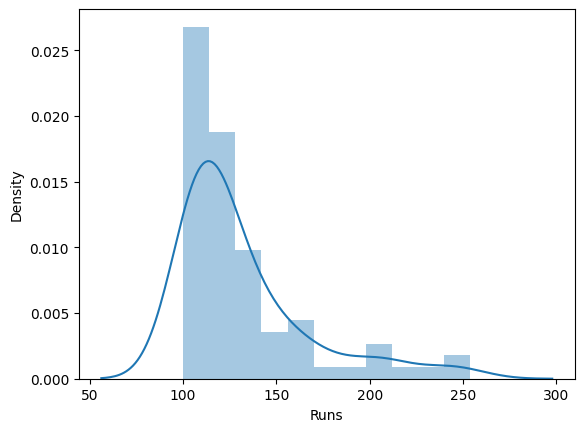

In [187]:
sns.distplot(df["Runs"])

In [188]:
df[df["Runs"]>=200]

,No.,Runs,Position,Ground,Result
36,37,200,4,Away,Won
37,38,211,4,Home,Won
40,41,235,4,Home,Won
42,43,204,4,Home,Won
50,51,213,4,Home,Won
51,52,243,4,Home,Drawn
68,69,254,4,Home,Won


In [189]:
df["Result"].unique()

array(['Won', 'Lost (D/L)', 'Lost', 'Drawn', 'Won (D/L)', 'Tied'],
      dtype=object)

In [190]:
df["Result"] = df["Result"].replace('Won (D/L)','Won')
df["Result"] = df["Result"].replace('Lost (D/L)','Lost')

In [191]:
df["Result"].unique()

array(['Won', 'Lost', 'Drawn', 'Tied'], dtype=object)

<Axes: xlabel='Result', ylabel='Ground'>

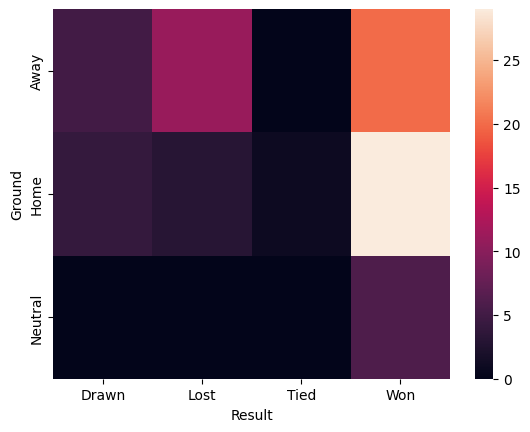

In [192]:
sns.heatmap(pd.crosstab(df["Ground"],df["Result"]))

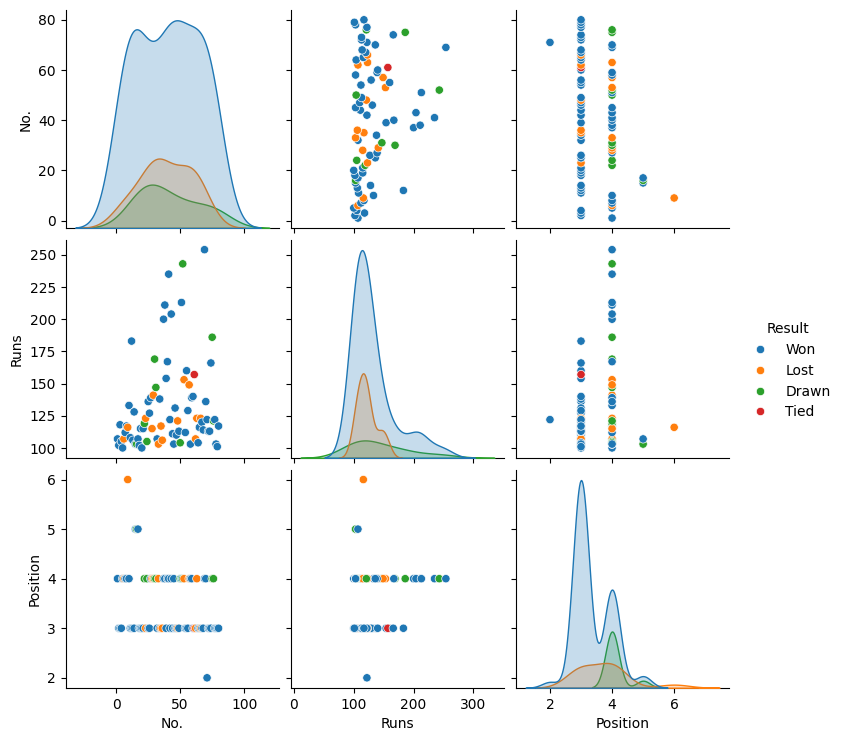

In [193]:
sns.pairplot(df,hue="Result")

In [194]:
df.head()

,No.,Runs,Position,Ground,Result
0,1,107,4,Home,Won
1,2,102,3,Away,Won
2,3,118,3,Home,Won
3,4,105,3,Home,Won
4,5,100,4,Away,Won


<Axes: ylabel='Position'>

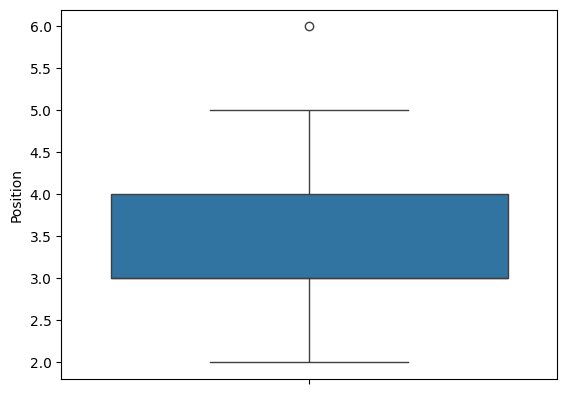

In [195]:
sns.boxplot(df["Position"])

In [196]:
df[df["Position"]==6]

,No.,Runs,Position,Ground,Result
8,9,116,6,Away,Lost


In [197]:
df.drop(8,inplace=True)

In [198]:
df[df["Position"]==6]

,No.,Runs,Position,Ground,Result


<Axes: ylabel='Position'>

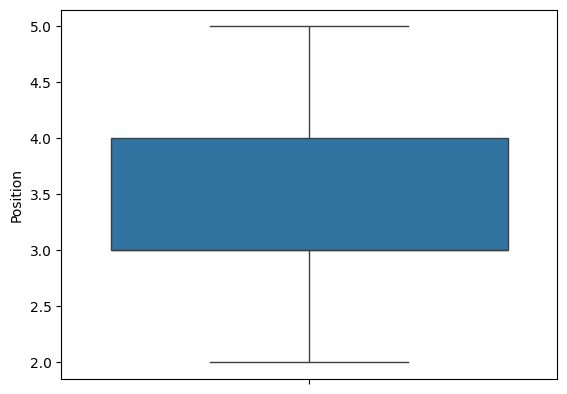

In [199]:
sns.boxplot(df["Position"])

<Axes: ylabel='Runs'>

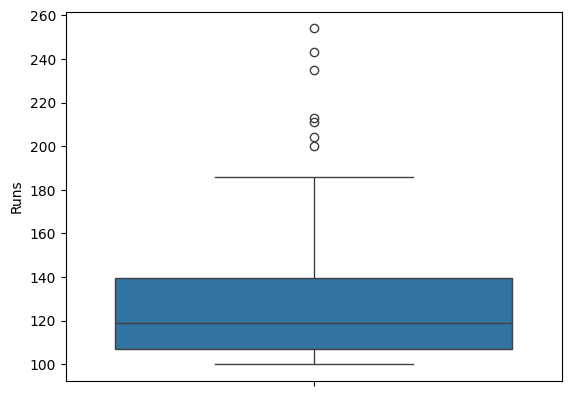

In [200]:
sns.boxplot(df["Runs"])

In [201]:
df.describe()

,No.,Runs,Position
count,79.000000,79.000000,79.000000
mean,40.898734,131.746835,3.468354
std,23.109325,35.274553,0.595613
min,1.000000,100.000000,2.000000
25%,21.500000,107.000000,3.000000
50%,41.000000,119.000000,3.000000
75%,60.500000,139.500000,4.000000
max,80.000000,254.000000,5.000000


In [202]:
percentile25 = df["Runs"].quantile(0.25)
percentile75 = df["Runs"].quantile(0.75)

In [203]:
percentile75

np.float64(139.5)

In [204]:
iqr = percentile75 - percentile25

In [205]:
iqr

np.float64(32.5)

In [206]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [207]:
upper_limit

np.float64(188.25)

In [208]:
df[df["Runs"]>upper_limit]

,No.,Runs,Position,Ground,Result
36,37,200,4,Away,Won
37,38,211,4,Home,Won
40,41,235,4,Home,Won
42,43,204,4,Home,Won
50,51,213,4,Home,Won
51,52,243,4,Home,Drawn
68,69,254,4,Home,Won


In [209]:
df.drop([36,37,40,42,50,51,68],inplace=True)

In [210]:
df[df["Runs"]>upper_limit]

,No.,Runs,Position,Ground,Result


<Axes: ylabel='Runs'>

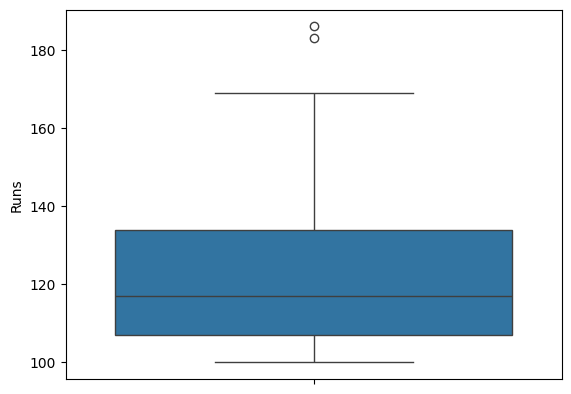

In [211]:
sns.boxplot(df["Runs"])

In [212]:
df["Runs"].describe()

count     72.000000
mean     122.888889
std       20.780242
min      100.000000
25%      107.000000
50%      117.000000
75%      133.750000
max      186.000000
Name: Runs, dtype: float64

In [213]:
percentile25 = df["Runs"].quantile(0.25)
percentile75 = df["Runs"].quantile(0.75)

In [214]:
percentile75

np.float64(133.75)

In [215]:
iqr = percentile75 - percentile25

In [216]:
iqr

np.float64(26.75)

In [217]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [218]:
df[df["Runs"]>upper_limit]

,No.,Runs,Position,Ground,Result
11,12,183,3,Neutral,Won
74,75,186,4,Home,Drawn


In [219]:
df.drop([11,74],inplace=True)

<Axes: ylabel='Runs'>

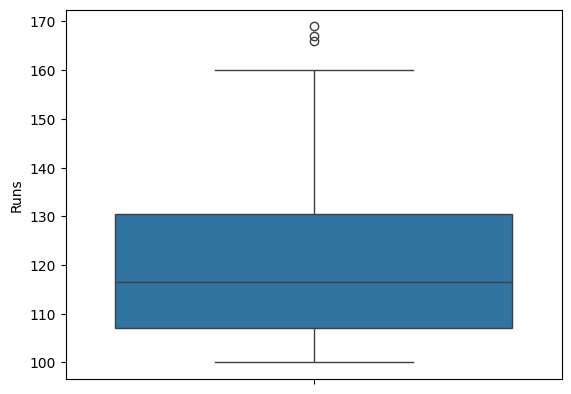

In [220]:
sns.boxplot(df["Runs"])

In [221]:
df.head()

,No.,Runs,Position,Ground,Result
0,1,107,4,Home,Won
1,2,102,3,Away,Won
2,3,118,3,Home,Won
3,4,105,3,Home,Won
4,5,100,4,Away,Won


In [222]:
df.isnull().sum()

No.         0
Runs        0
Position    0
Ground      1
Result      0
dtype: int64

In [223]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=["Result"]),df["Result"],
                                                 test_size=0.2,random_state=42)

In [224]:
X_train.head()

,No.,Runs,Position,Ground
71,72,113,3,Away
32,33,103,4,Away
66,67,120,3,Away
39,40,167,4,Home
65,66,123,3,Home


In [277]:
tnf1 = ColumnTransformer([
    ('ground_imputed',SimpleImputer(strategy='most_frequent'),['Ground'])
],remainder='passthrough')

In [278]:
z = tnf1.fit_transform(X_train)

In [279]:
s = pd.DataFrame(z)
s.isnull().sum()

0    0
1    0
2    0
3    0
dtype: int64

In [280]:
X_train.columns

Index(['No.', 'Runs', 'Position', 'Ground'], dtype='object')

In [281]:
X_train.isnull().sum()

No.         0
Runs        0
Position    0
Ground      1
dtype: int64

In [282]:
tnf1.get_feature_names_out()

array(['ground_imputed__Ground', 'remainder__No.', 'remainder__Runs',
       'remainder__Position'], dtype=object)

In [292]:
tnf2 = ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[0])
],remainder='passthrough')

In [293]:
tnf2.fit_transform(X_train)

array([[0.0, 0.0, 0.0, ..., 113, 3, 'Away'],
       [0.0, 0.0, 0.0, ..., 103, 4, 'Away'],
       [0.0, 0.0, 0.0, ..., 120, 3, 'Away'],
       ...,
       [0.0, 0.0, 0.0, ..., 136, 4, 'Home'],
       [0.0, 0.0, 0.0, ..., 107, 5, 'Home'],
       [0.0, 0.0, 0.0, ..., 140, 3, 'Home']], shape=(56, 59), dtype=object)

In [294]:
tnf2.get_feature_names_out()

array(['ohe__No._2', 'ohe__No._3', 'ohe__No._4', 'ohe__No._7',
       'ohe__No._8', 'ohe__No._10', 'ohe__No._14', 'ohe__No._16',
       'ohe__No._17', 'ohe__No._18', 'ohe__No._19', 'ohe__No._20',
       'ohe__No._22', 'ohe__No._23', 'ohe__No._24', 'ohe__No._26',
       'ohe__No._27', 'ohe__No._28', 'ohe__No._29', 'ohe__No._30',
       'ohe__No._31', 'ohe__No._32', 'ohe__No._33', 'ohe__No._35',
       'ohe__No._39', 'ohe__No._40', 'ohe__No._42', 'ohe__No._44',
       'ohe__No._45', 'ohe__No._46', 'ohe__No._47', 'ohe__No._48',
       'ohe__No._49', 'ohe__No._50', 'ohe__No._53', 'ohe__No._55',
       'ohe__No._56', 'ohe__No._57', 'ohe__No._59', 'ohe__No._60',
       'ohe__No._61', 'ohe__No._62', 'ohe__No._64', 'ohe__No._65',
       'ohe__No._66', 'ohe__No._67', 'ohe__No._68', 'ohe__No._70',
       'ohe__No._71', 'ohe__No._72', 'ohe__No._73', 'ohe__No._74',
       'ohe__No._76', 'ohe__No._77', 'ohe__No._79', 'ohe__No._80',
       'remainder__Runs', 'remainder__Position', 'remainder__Ground

In [295]:
tnf3 = LogisticRegression()

In [296]:
le = LabelEncoder()
le.fit_transform(y_train)

array([3, 1, 3, 3, 1, 3, 3, 3, 3, 0, 3, 1, 3, 1, 3, 0, 3, 3, 1, 3, 0, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 1, 1, 1, 3, 3, 3, 3, 1, 3, 3, 3,
       3, 0, 0, 3, 2, 0, 3, 3, 1, 3, 3, 3])

In [297]:
le.transform(y_test)

array([3, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, 3, 3, 1])

In [299]:
pipe = make_pipeline(tnf1,tnf2,tnf3)

In [300]:
pipe.fit(X_train,y_train)

c:\Users\DELL\anaconda3\Newfolder\envs\mlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer-1', ...), ('columntransformer-2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Drawn','Lost','Tied','Won']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['No.','Runs','Position','Ground']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ground_imputed', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [301]:
y_pred = pipe.predict(X_test)

In [302]:
y_pred

array(['Won', 'Won', 'Won', 'Drawn', 'Won', 'Won', 'Won', 'Won', 'Won',
       'Drawn', 'Won', 'Won', 'Won', 'Drawn'], dtype=object)

In [303]:
y_test

24     Won
0      Won
57     Won
4      Won
62    Lost
20     Won
12     Won
35    Lost
53     Won
14     Won
33     Won
10     Won
77     Won
5     Lost
Name: Result, dtype: object

In [304]:
accuracy_score(y_test,y_pred)

0.6428571428571429

In [305]:
cross_val_score(pipe,X_train,y_train,cv=5,).mean()

c:\Users\DELL\anaconda3\Newfolder\envs\mlenv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\DELL\anaconda3\Newfolder\envs\mlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\DELL\anaconda3\Newfolder\envs\mlenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=

np.float64(0.6424242424242423)